# Week 4 - Univariate Analysis, part 2

# 1. Lesson - None

# 2. Weekly graph question

Below are a histogram and boxplot representation of the same data. A pharmacy is keeping a record of the prices of the drugs that it sells, and an administrator wants to know how much the more expensive drugs tend to cost, in the context of the other prices.

Please write a short explanation of the pros and cons of these two representations. Which would you choose? How would you modify the formatting, if at all, to make it more visually interesting, clear, or informative?

In [1]:
import numpy as np
import pandas as pd

np.random.seed(0)
num_data = 100
data = np.exp(np.random.uniform(size = num_data) * 4)
df = pd.DataFrame(data.T, columns = ["data"])

The 75th percentile is: data    15.457656
Name: 0.75, dtype: float64


<Axes: ylabel='Frequency'>

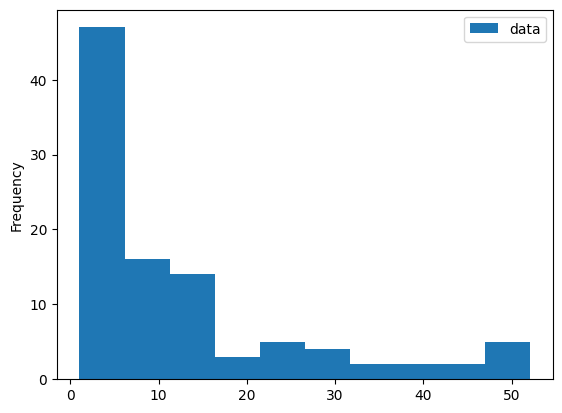

In [2]:
print("The 75th percentile is:", df.quantile(q = 0.75))
df.plot.hist()

<Axes: >

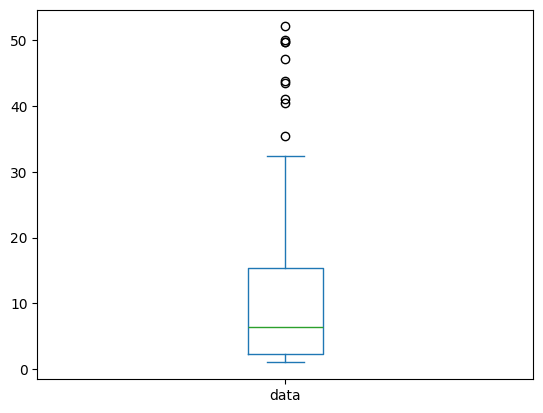

In [3]:
df.plot.box()

**MAKSIM HAURYLIK:**
When comparing histogram and boxplot, histogram seems a better choice for understanding overall price structure, it shows distribution shape, skewness, and clustering, but can be sensitive to the number of bins chosen. Boxplot shows median, quartiles and outliers, but does not show the distribution shape

If the administrator wants to understand how expensive drugs compare to typical prices, the boxplot seems more effective. But if they want to understand the distribution shape, maybe they should better use the histogram


# 3. Homework - working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do:

- Draw histograms and histogram variants for each feature or column.  (Swarm plot, kde plot, violin plot).

- Draw grouped histograms.  For instance, if you have tree heights for both maple and oak trees, you could draw histograms for both.

- Draw a bar plot to indicate total counts of each categorical variable in a given column.

- Find means, medians, and modes.

### Conclusions:

- Explain what conclusions you would draw from this analysis: are the data what you expect?  Are the data likely to be usable?  If they are not useable, find some new data!

- What is the overall shape of the distribution?  Is it normal, skewed, bimodal, uniform, etc.?

- Are there any outliers present?  (Data points that are far from the others.)

- If there are multiple related histograms, how does the distribution change across different groups?

- What are the minimum and maximum values represented in each histogram?

- How do bin sizes affect the histogram?  Does changing the bin width reveal different patterns in the data?

- Does the distribution appear normal, or does it have a different distribution?

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
df_ecom = pd.read_csv("US  E-commerce records 2020.csv", encoding="latin1")
df_ecom.columns = df_ecom.columns.str.strip()

print("Dataset shape:", df_ecom.shape)
print("\nColumns:")
print(df_ecom.columns.tolist())

if "Order Date" in df_ecom.columns:
    df_ecom["Order Date"] = pd.to_datetime(df_ecom["Order Date"], errors="coerce")

print("\nMissing values:")
print(df_ecom.isnull().sum())

print("\nDuplicate rows:", df_ecom.duplicated().sum())

Dataset shape: (3312, 19)

Columns:
['Order Date', 'Row ID', 'Order ID', 'Ship Mode', 'Customer ID', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']

Missing values:
Order Date      0
Row ID          0
Order ID        0
Ship Mode       0
Customer ID     0
Segment         0
Country         0
City            0
State           0
Postal Code     0
Region          0
Product ID      0
Category        0
Sub-Category    0
Product Name    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64

Duplicate rows: 0


/tmp/ipykernel_2901/3682599876.py:15: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_ecom["Order Date"] = pd.to_datetime(df_ecom["Order Date"], errors="coerce")


In [10]:
numeric_cols = df_ecom.select_dtypes(include="number").columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in ["Row ID", "Postal Code"]]

print("\nNumeric columns used:", numeric_cols)

summary_stats = pd.DataFrame({
    "Mean": df_ecom[numeric_cols].mean(),
    "Median": df_ecom[numeric_cols].median(),
    "Mode": df_ecom[numeric_cols].mode().iloc[0]
})

summary_stats



Numeric columns used: ['Sales', 'Quantity', 'Discount', 'Profit']


,Mean,Median,Mode
Sales,221.381418,53.8100,12.96
Quantity,3.766908,3.0000,2.00
Discount,0.156467,0.2000,0.00
Profit,28.212340,8.2968,0.00


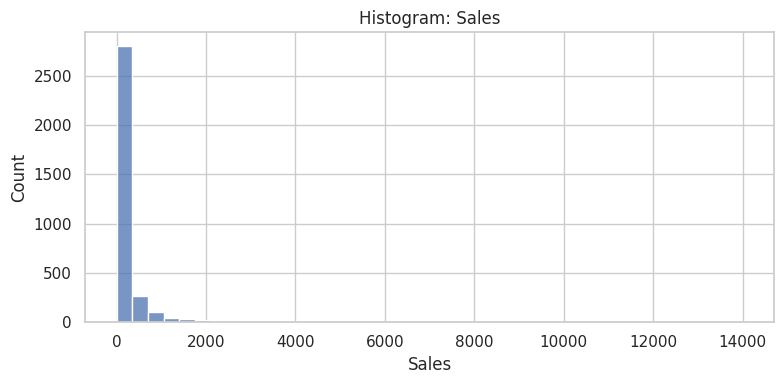

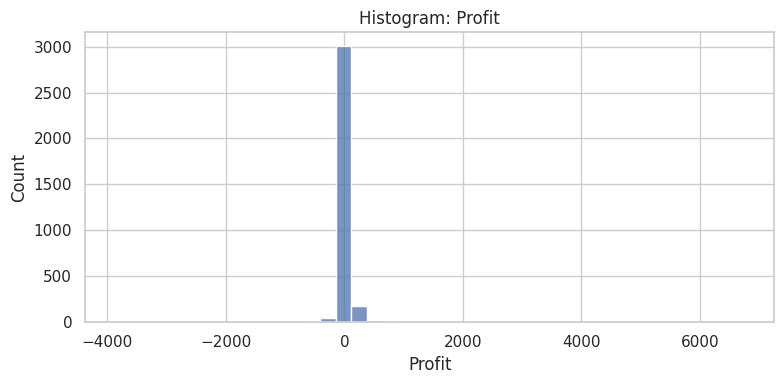

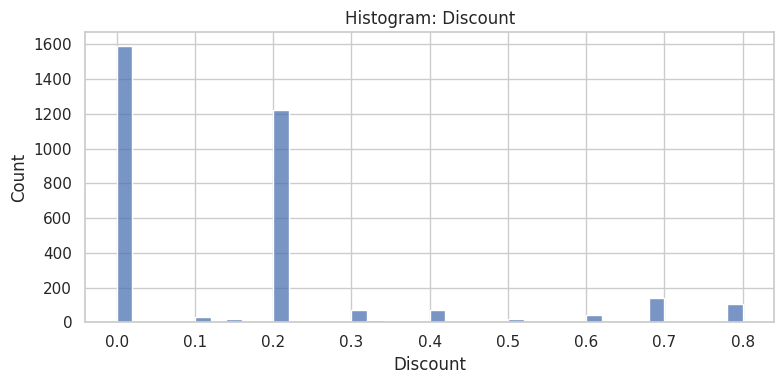

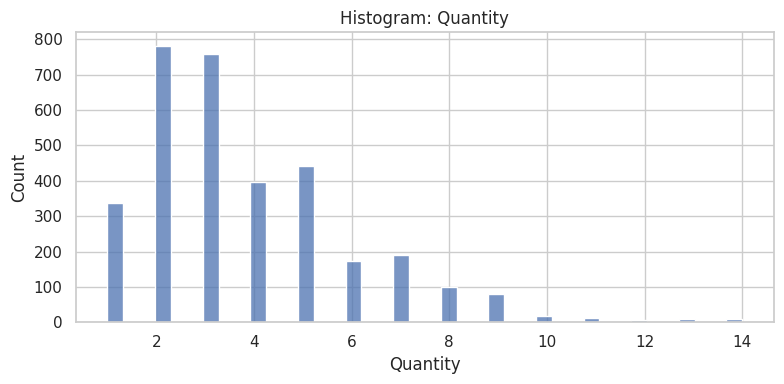

In [13]:
for col in ["Sales", "Profit", "Discount", "Quantity"]:
    if col in df_ecom.columns:
        plt.figure(figsize=(8,4))
        sns.histplot(df_ecom[col], bins=40)
        plt.title(f"Histogram: {col}")
        plt.tight_layout()
        plt.show()

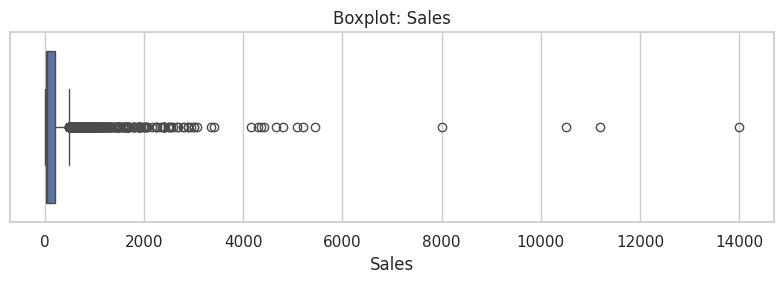

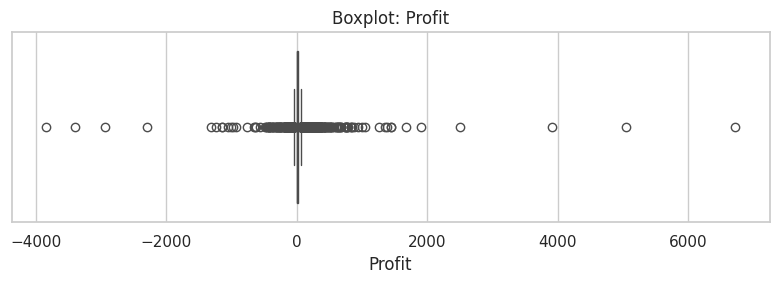

In [14]:
for col in ["Sales", "Profit"]:
    if col in df_ecom.columns:
        plt.figure(figsize=(8,3))
        sns.boxplot(x=df_ecom[col])
        plt.title(f"Boxplot: {col}")
        plt.tight_layout()
        plt.show()


Categorical columns found: ['Ship Mode', 'Segment', 'Region', 'Category', 'Sub-Category']


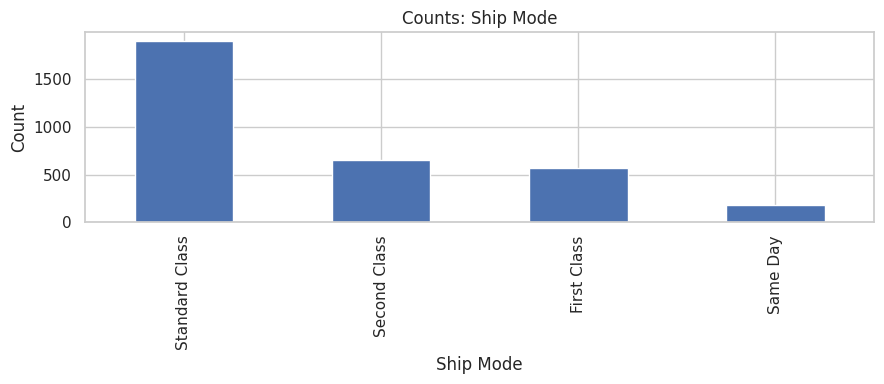

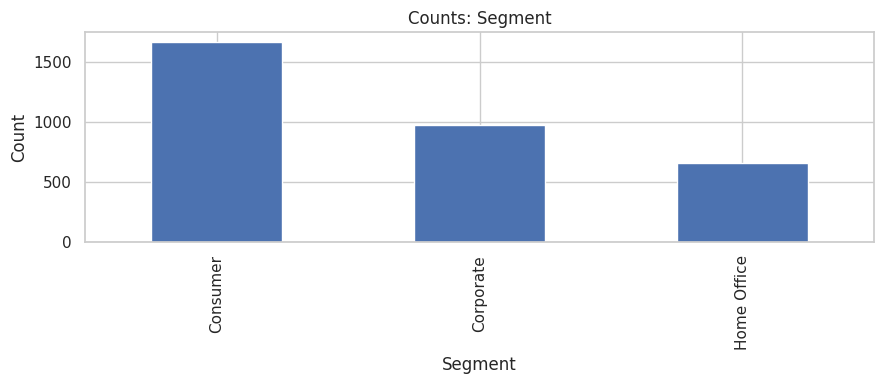

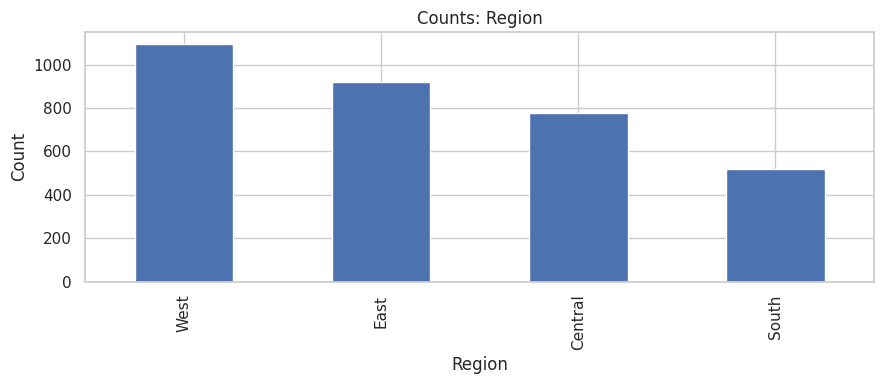

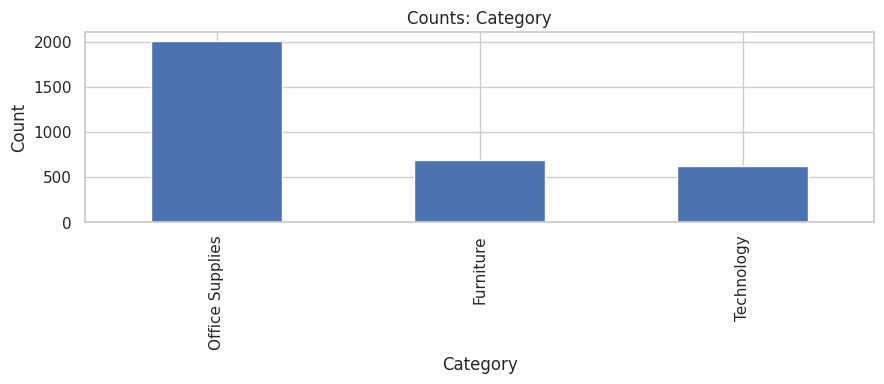

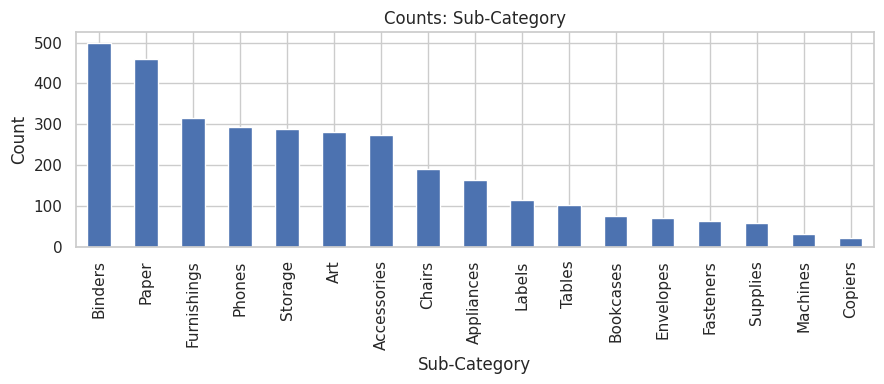

In [15]:
cat_cols = ["Ship Mode", "Segment", "Region", "Category", "Sub-Category"]
cat_cols = [c for c in cat_cols if c in df_ecom.columns]

print("\nCategorical columns found:", cat_cols)

for col in cat_cols:
    counts = df_ecom[col].value_counts(dropna=True)

    if len(counts) == 0:
        print(f"Skipping {col} (no valid values)")
        continue

    plt.figure(figsize=(9,4))
    counts.plot(kind="bar")
    plt.title(f"Counts: {col}")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

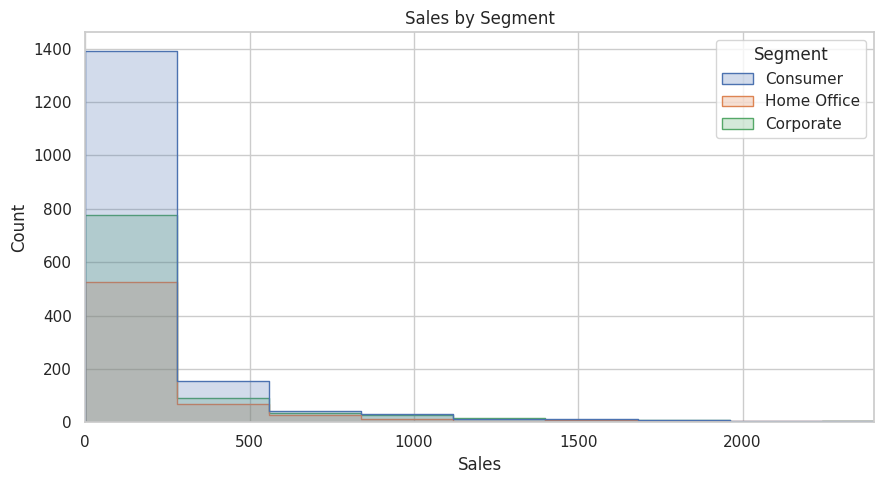

In [16]:
if ("Sales" in df_ecom.columns) and ("Segment" in df_ecom.columns):
    plt.figure(figsize=(9,5))
    sns.histplot(
        data=df_ecom,
        x="Sales",
        hue="Segment",
        bins=50,
        element="step"
    )
    plt.xlim(0, df_ecom["Sales"].quantile(0.99))
    plt.title("Sales by Segment")
    plt.tight_layout()
    plt.show()


Top 10 Sub-Categories by Profit:
Sub-Category
Copiers        25031.7902
Accessories    15672.3570
Phones         12849.3250
Paper          12040.8434
Appliances      7865.2683
Binders         7669.7418
Chairs          7643.5493
Storage         7402.8007
Furnishings     4099.1628
Art             2221.9631
Name: Profit, dtype: float64

Bottom 5 Sub-Categories by Profit:
Sub-Category
Fasteners     304.9489
Bookcases    -583.6261
Supplies     -955.3128
Machines    -2869.2156
Tables      -8140.6947
Name: Profit, dtype: float64


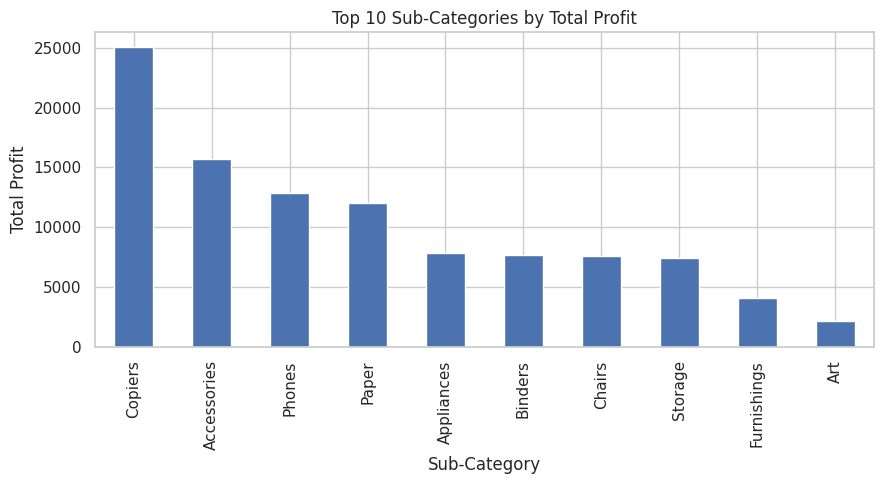

In [18]:
if ("Profit" in df_ecom.columns) and ("Sub-Category" in df_ecom.columns):
    profit_by_sub = df_ecom.groupby("Sub-Category")["Profit"].sum().sort_values(ascending=False)

    print("\nTop 10 Sub-Categories by Profit:")
    print(profit_by_sub.head(10))

    print("\nBottom 5 Sub-Categories by Profit:")
    print(profit_by_sub.tail(5))

    plt.figure(figsize=(9,5))
    profit_by_sub.head(10).plot(kind="bar")
    plt.title("Top 10 Sub-Categories by Total Profit")
    plt.ylabel("Total Profit")
    plt.tight_layout()
    plt.show()


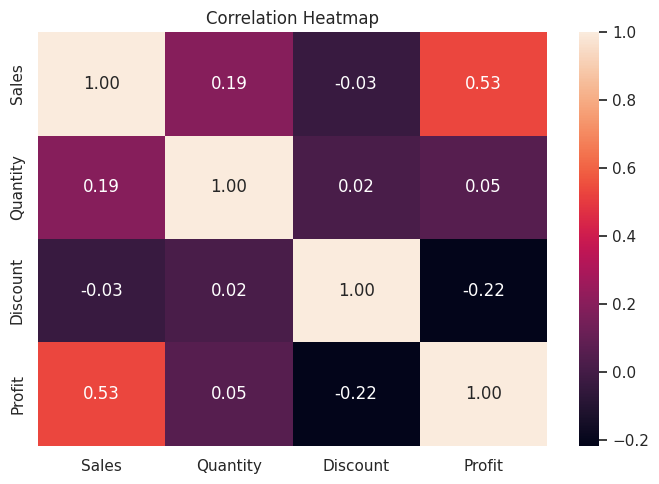

In [19]:
if len(numeric_cols) >= 2:
    plt.figure(figsize=(7,5))
    sns.heatmap(df_ecom[numeric_cols].corr(), annot=True, fmt=".2f")
    plt.title("Correlation Heatmap")
    plt.tight_layout()
    plt.show()

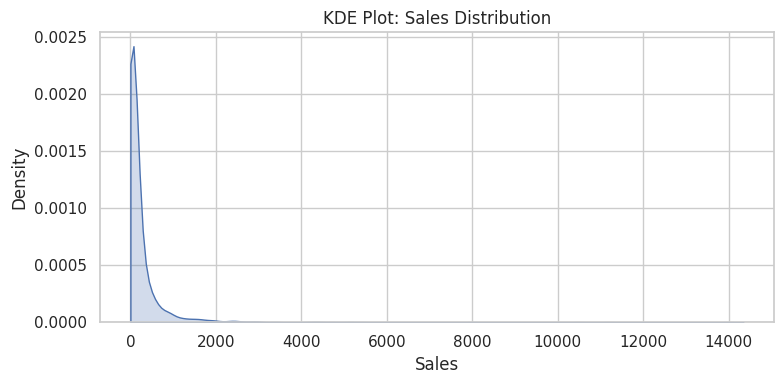

In [20]:
if "Sales" in df_ecom.columns:
    plt.figure(figsize=(8,4))
    sns.kdeplot(df_ecom["Sales"], fill=True, clip=(0, None))
    plt.title("KDE Plot: Sales Distribution")
    plt.xlabel("Sales")
    plt.ylabel("Density")
    plt.tight_layout()
    plt.show()

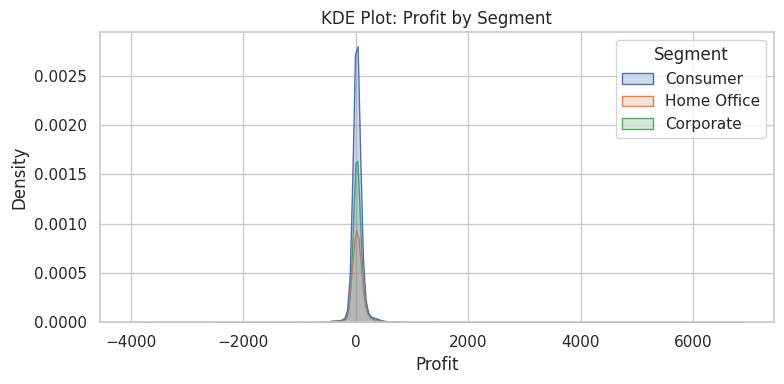

In [21]:
if ("Profit" in df_ecom.columns) and ("Segment" in df_ecom.columns):
    plt.figure(figsize=(8,4))
    sns.kdeplot(data=df_ecom, x="Profit", hue="Segment", fill=True)
    plt.title("KDE Plot: Profit by Segment")
    plt.tight_layout()
    plt.show()


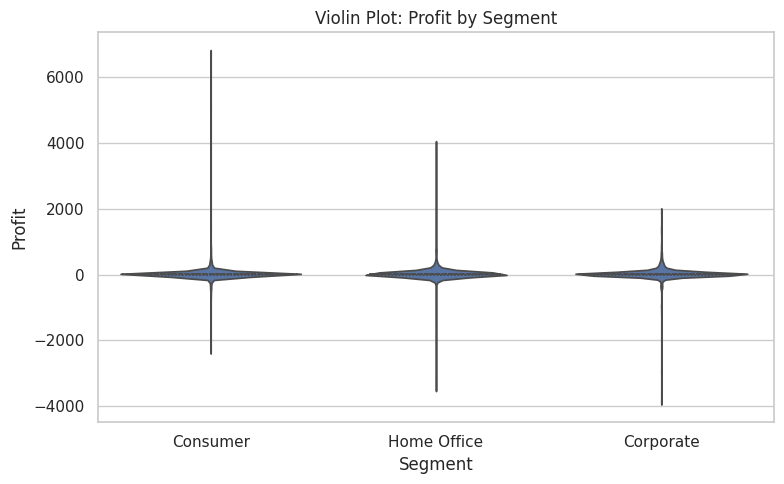

In [22]:
if ("Profit" in df_ecom.columns) and ("Segment" in df_ecom.columns):
    plt.figure(figsize=(8,5))
    sns.violinplot(data=df_ecom, x="Segment", y="Profit", inner="quartile")
    plt.title("Violin Plot: Profit by Segment")
    plt.tight_layout()
    plt.show()

/usr/local/python/3.12.1/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 5.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/python/3.12.1/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 40.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/python/3.12.1/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 21.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/python/3.12.1/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 16.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/python/3.12.1/lib/python3.12/site-packages/seaborn

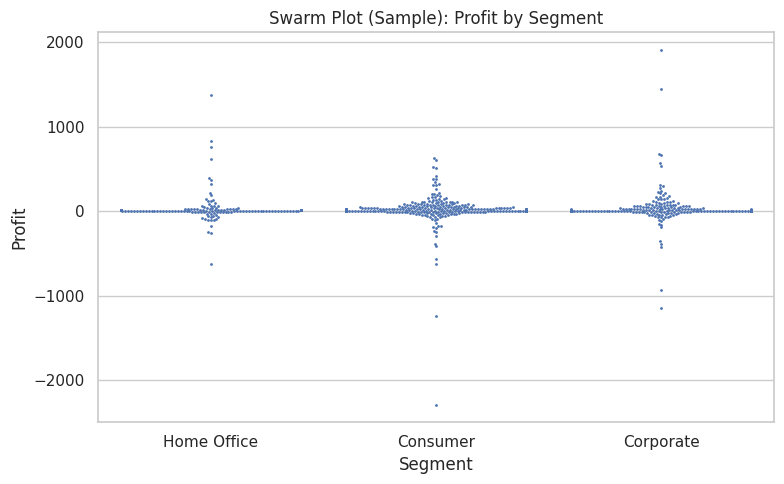

In [23]:
if ("Profit" in df_ecom.columns) and ("Segment" in df_ecom.columns):
    sample_df = df_ecom.sample(min(800, len(df_ecom)), random_state=0)

    plt.figure(figsize=(8,5))
    sns.swarmplot(data=sample_df, x="Segment", y="Profit", size=2)
    plt.title("Swarm Plot (Sample): Profit by Segment")
    plt.tight_layout()
    plt.show()

**Conclusions**

**MAKSIM HAURYLIK**


* I couldn't find any miissing values and/or duplicates. The data seems usable for further analysis 
* The dataset loads correctly only when using "latin1" encoding. 
* The histograms show skewness. **Profit** includes both positive and negative values, indicating that some orders are unprofitable. **Sales** distribution is strongly right-skewed.
* The boxplots confirm there can be extreme values (outliers) in both Sales and Profit.
* The distributions can be uneven across Segment, Region, Category and Sub-Category. Some segments and sub-categories contribute disproportionatealy to total profit
* Yes, the histogram changes its shape depending on the bin size usually. Here I did not notice anything unexpected

In general, this dataset seems to be quite realistic

# 4. Storytelling With Data graph

Reproduce any graph of your choice in p. 52-68 of the Storytelling With Data book as best you can.  (The second half of chapter two).  You do not have to get the exact data values right, just the overall look and feel.

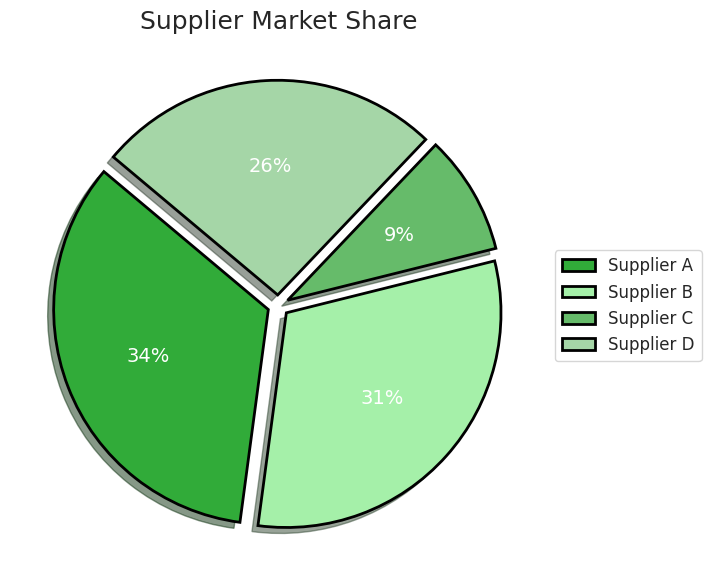

In [32]:

labels = ["Supplier A", "Supplier B", "Supplier C", "Supplier D"]
sizes = [34, 31, 9, 26]
colors = ["#31ab39", "#a5f0a9", "#66bb6a", "#a5d6a7"]

explode = [0.05, 0.05, 0.05, 0.05]

fig, ax = plt.subplots(figsize=(8, 6))
wedges, texts, autotexts = ax.pie(
    sizes,
    explode=explode,
    colors=colors,
    autopct="%1.0f%%",
    startangle=140,
    shadow=True,
    textprops={"fontsize": 14, "color": "white"}
)

for w in wedges:
    w.set_linewidth(2)
    w.set_edgecolor("black")

plt.title("Supplier Market Share", fontsize=18)

plt.legend(
    wedges,
    labels,
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    fontsize=12
)

plt.tight_layout()
plt.show()